# CS-4063: NLP Assignment 3 — Transformers + RAG
## Amazon Reviews: Encoder + Retrieval + Decoder Pipeline



In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# import os
# BASE        = '/content/drive/MyDrive/NLP Assg03'
# DATA_DIR    = f'{BASE}/data'
# RESULTS_DIR = f'{BASE}/results'
# MODELS_DIR  = f'{BASE}/models'
# for d in [DATA_DIR, RESULTS_DIR, MODELS_DIR]:
#     os.makedirs(d, exist_ok=True)
# print('Directories ready:', BASE)

In [ ]:
#  1. Mount Drive
from google.colab import drive
drive.mount('/content/drive')

#  2. Imports
import os
import json

#  3. Paths (FIXED here )
BASE = '/content/drive/MyDrive/NLP Assg03'
DATA_DIR = f'{BASE}/Dataset'   #  capital D

RESULTS_DIR = f'{BASE}/results'
MODELS_DIR  = f'{BASE}/models'

#  4. Create folders
for d in [RESULTS_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

print(' Directories ready:', BASE)

#  5. Auto-detect and load JSON files
def load_json_lines(filepath, limit=1000):
    data = []
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            data.append(json.loads(line))
            if i >= limit:
                break
    return data

datasets = {}

print("\n Searching for dataset files...")

for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.endswith('.json'):
            full_path = os.path.join(root, file)
            key = file.lower().split('_')[0]  # beauty, electronics, etc.

            print(f" Found: {full_path}")

            datasets[key] = load_json_lines(full_path, limit=1000)
            print(f"   Loaded {key}: {len(datasets[key])} records")

#  6. Safe check before access
if "beauty" in datasets:
    print("\n Sample beauty record:")
    print(datasets["beauty"][0])
else:
    print("\n Beauty dataset not found")

Mounted at /content/drive
 Directories ready: /content/drive/MyDrive/NLP Assg03

 Searching for dataset files...
 Found: /content/drive/MyDrive/NLP Assg03/Dataset/beauty.json/Beauty_5.json
   Loaded beauty: 1001 records
 Found: /content/drive/MyDrive/NLP Assg03/Dataset/home.json/Home_and_Kitchen_5 (1).json
   Loaded home: 1001 records
 Found: /content/drive/MyDrive/NLP Assg03/Dataset/home.json/Home_and_Kitchen_5.json
   Loaded home: 1001 records
 Found: /content/drive/MyDrive/NLP Assg03/Dataset/electronics.json/Electronics_5.json
   Loaded electronics: 1001 records
 Found: /content/drive/MyDrive/NLP Assg03/Dataset/sports.json/Sports_and_Outdoors_5.json
   Loaded sports: 1001 records
 Found: /content/drive/MyDrive/NLP Assg03/Dataset/cellphones.json/Cell_Phones_and_Accessories_5.json
   Loaded cell: 1001 records

 Sample beauty record:
{'reviewerID': 'A1YJEY40YUW4SE', 'asin': '7806397051', 'reviewerName': 'Andrea', 'helpful': [3, 4], 'reviewText': 'Very oily and creamy. Not at all what I

In [ ]:
import json, re, math, random, pickle
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cuda


In [ ]:
CFG = dict(
    samples_per_cat = 12000,  # 10-15k per category
    max_len         = 128,    # encoder sequence length
    vocab_size      = 20000,
    seed            = 42,
    d_model         = 128,
    n_heads         = 4,
    n_layers        = 2,
    d_ff            = 256,
    dropout         = 0.1,
    batch_size      = 64,
    enc_epochs      = 10,
    dec_epochs      = 10,
    lr              = 3e-4,
    warmup_steps    = 500,
    top_k           = 3,      # retrieved neighbours
    max_gen_len     = 40,
)
random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])
print(CFG)

{'samples_per_cat': 12000, 'max_len': 128, 'vocab_size': 20000, 'seed': 42, 'd_model': 128, 'n_heads': 4, 'n_layers': 2, 'd_ff': 256, 'dropout': 0.1, 'batch_size': 64, 'enc_epochs': 10, 'dec_epochs': 10, 'lr': 0.0003, 'warmup_steps': 500, 'top_k': 3, 'max_gen_len': 40}


## Dataset Loading & Preprocessing

In [ ]:
FILES = [
    ('Home_and_Kitchen',           'home.json',        'Home_and_Kitchen_5.json'),
    ('Beauty',                     'beauty.json',      'Beauty_5.json'),
    ('Cell_Phones_and_Accessories','cellphones.json', 'Cell_Phones_and_Accessories_5.json'),
    ('Electronics',                'electronics.json', 'Electronics_5.json'),
    ('Sports_and_Outdoors',        'sports.json',      'Sports_and_Outdoors_5.json'),
]

def load_category(path, n=CFG['samples_per_cat']):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                obj = json.loads(line)
                if 'reviewText' in obj and 'overall' in obj:
                    rows.append({'text': obj['reviewText'], 'rating': int(obj['overall'])})
                if len(rows) == n:
                    break
            except Exception:
                pass
    return rows

all_rows = []

for cat, folder, fname in FILES:
    path = os.path.join(DATA_DIR, folder, fname)

    if not os.path.exists(path):
        print(f'[SKIP] {path} not found')
        continue

    rows = load_category(path)

    for r in rows:
        r['category'] = cat

    all_rows.extend(rows)
    print(f'{cat}: {len(rows)} reviews')

# Create DataFrame from loaded rows
df = pd.DataFrame(all_rows)
print(f'Total reviews loaded: {len(df)}')
print(df.head(2))


Home_and_Kitchen: 12000 reviews
Beauty: 12000 reviews
Cell_Phones_and_Accessories: 12000 reviews
Electronics: 12000 reviews
Sports_and_Outdoors: 12000 reviews
Total reviews loaded: 60000
                                                text  rating          category
0  My daughter wanted this book and the price on ...       5  Home_and_Kitchen
1  I bought this zoku quick pop for my daughterr ...       5  Home_and_Kitchen


In [ ]:
import re

# 🔹 Ensure df is not empty and has required columns
if df.empty:
    raise ValueError(" DataFrame is empty. Fix data loading step first.")

required_cols = ['text', 'rating']
for col in required_cols:
    if col not in df.columns:
        raise KeyError(f" Missing column: {col}")

# Label A: Sentiment  (0=Negative 1-2, 1=Neutral 3, 2=Positive 4-5)
# Label B: Length bucket  (0=short<50w, 1=medium, 2=long>150w)

def clean(text):
    text = str(text).lower()   #  ensure no None/NaN crash
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def sentiment_label(r):
    return 0 if r <= 2 else (1 if r == 3 else 2)

def length_label(text):
    wc = len(str(text).split())   #  safe conversion
    return 0 if wc < 50 else (1 if wc < 150 else 2)

df['clean']    = df['text'].apply(clean)
df['sent_lbl'] = df['rating'].apply(sentiment_label)
df['len_lbl']  = df['text'].apply(length_label)

# 🔹 Shuffle + split (unchanged logic)
df = df.sample(frac=1, random_state=CFG['seed']).reset_index(drop=True)

n = len(df)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

train_df = df.iloc[:n_train]
val_df   = df.iloc[n_train:n_train+n_val]
test_df  = df.iloc[n_train+n_val:]

print(f'Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}')

Train 42000 | Val 9000 | Test 9000


In [ ]:
PAD, UNK, BOS, EOS = '<PAD>', '<UNK>', '<BOS>', '<EOS>'
SPECIALS = [PAD, UNK, BOS, EOS]

def tokenize(text): return text.split()

freq = Counter()
for txt in train_df['clean']: freq.update(tokenize(txt))

vocab_words = [w for w, _ in freq.most_common(CFG['vocab_size'] - len(SPECIALS))]
vocab = SPECIALS + vocab_words
w2i = {w: i for i, w in enumerate(vocab)}
i2w = {i: w for w, i in w2i.items()}

def encode(text, max_len=CFG['max_len']):
    ids = [w2i.get(t, w2i[UNK]) for t in tokenize(text)][:max_len]
    ids += [w2i[PAD]] * (max_len - len(ids))
    return ids

print(f'Vocab size: {len(vocab)}')

Vocab size: 20000


In [ ]:
class ReviewDataset(Dataset):
    def __init__(self, dataframe):
        self.input_ids = torch.tensor(
            [encode(t) for t in dataframe['clean']], dtype=torch.long)
        self.sent_lbl = torch.tensor(dataframe['sent_lbl'].values, dtype=torch.long)
        self.len_lbl  = torch.tensor(dataframe['len_lbl'].values,  dtype=torch.long)
    def __len__(self): return len(self.input_ids)
    def __getitem__(self, i): return self.input_ids[i], self.sent_lbl[i], self.len_lbl[i]

train_ds = ReviewDataset(train_df)
val_ds   = ReviewDataset(val_df)
test_ds  = ReviewDataset(test_df)
train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'])
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'])
print('Loaders ready.')

Loaders ready.


## Part A — Encoder-Only Transformer (Multi-Task)

In [ ]:
class ScaledDotProductAttention(nn.Module):
    """Scaled dot-product attention built from scratch."""
    def __init__(self, d_k, dropout=0.1):
        super().__init__()
        self.scale   = math.sqrt(d_k)
        self.dropout = nn.Dropout(dropout)
    def forward(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn = self.dropout(F.softmax(scores, dim=-1))
        return torch.matmul(attn, V), attn


class MultiHeadAttention(nn.Module):
    """Multi-head attention -- no nn.MultiheadAttention used."""
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)
        self.attn    = ScaledDotProductAttention(self.d_k, dropout)
        self.dropout = nn.Dropout(dropout)
    def split_heads(self, x):
        B, S, _ = x.shape
        return x.view(B, S, self.n_heads, self.d_k).transpose(1, 2)
    def forward(self, Q, K, V, mask=None):
        B = Q.size(0)
        Q = self.split_heads(self.W_Q(Q))
        K = self.split_heads(self.W_K(K))
        V = self.split_heads(self.W_V(V))
        out, _ = self.attn(Q, K, V, mask)
        out = out.transpose(1, 2).contiguous().view(B, -1, self.n_heads * self.d_k)
        return self.W_O(out)

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model))
    def forward(self, x): return self.net(x)


class EncoderBlock(nn.Module):
    """MHA -> Add&Norm -> FFN -> Add&Norm"""
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.mha  = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn  = FeedForward(d_model, d_ff, dropout)
        self.ln1  = nn.LayerNorm(d_model)
        self.ln2  = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, mask=None):
        x = self.ln1(x + self.drop(self.mha(x, x, x, mask)))
        x = self.ln2(x + self.drop(self.ffn(x)))
        return x

In [ ]:
class EncoderModel(nn.Module):
    """
    Encoder-only Transformer.
    Returns: sentiment logits, length-bucket logits, CLS embedding.
    """
    def __init__(self, vocab_size, d_model, n_heads, n_layers,
                 d_ff, max_len, dropout, n_sent=3, n_len=3):
        super().__init__()
        self.embed  = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pe     = PositionalEncoding(d_model, max_len, dropout)
        self.blocks = nn.ModuleList(
            [EncoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.norm      = nn.LayerNorm(d_model)
        self.sent_head = nn.Linear(d_model, n_sent)
        self.len_head  = nn.Linear(d_model, n_len)
    def forward(self, ids):
        mask    = (ids != 0).unsqueeze(1).unsqueeze(2)  # padding mask
        x       = self.pe(self.embed(ids))
        for blk in self.blocks: x = blk(x, mask)
        x       = self.norm(x)
        non_pad = (ids != 0).float().unsqueeze(-1)
        cls     = (x * non_pad).sum(1) / non_pad.sum(1)  # mean pool
        return self.sent_head(cls), self.len_head(cls), cls

enc_model = EncoderModel(
    vocab_size=len(vocab), d_model=CFG['d_model'], n_heads=CFG['n_heads'],
    n_layers=CFG['n_layers'], d_ff=CFG['d_ff'],
    max_len=CFG['max_len'], dropout=CFG['dropout']
).to(DEVICE)
print('Encoder params:', sum(p.numel() for p in enc_model.parameters()))

Encoder params: 2825990


In [ ]:
optimizer  = torch.optim.Adam(enc_model.parameters(), lr=CFG['lr'])
total_steps = CFG['enc_epochs'] * len(train_loader)
def lr_lambda(step):
    if step < CFG['warmup_steps']:
        return step / max(1, CFG['warmup_steps'])
    return max(0.1, 0.5 * (1 + math.cos(math.pi * step / total_steps)))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
ce = nn.CrossEntropyLoss()

train_losses, val_losses = [], []
for epoch in range(CFG['enc_epochs']):
    enc_model.train(); ep_loss = 0
    for ids, slbl, llbl in train_loader:
        ids, slbl, llbl = ids.to(DEVICE), slbl.to(DEVICE), llbl.to(DEVICE)
        s, l, _ = enc_model(ids)
        loss = ce(s, slbl) + ce(l, llbl)  # combined multi-task loss
        optimizer.zero_grad(); loss.backward(); optimizer.step(); scheduler.step()
        ep_loss += loss.item()
    enc_model.eval(); vl = 0
    with torch.no_grad():
        for ids, slbl, llbl in val_loader:
            ids, slbl, llbl = ids.to(DEVICE), slbl.to(DEVICE), llbl.to(DEVICE)
            s, l, _ = enc_model(ids)
            vl += (ce(s, slbl) + ce(l, llbl)).item()
    train_losses.append(ep_loss / len(train_loader))
    val_losses.append(vl / len(val_loader))
    print(f'Epoch {epoch+1}/{CFG["enc_epochs"]} | Train {train_losses[-1]:.4f} | Val {val_losses[-1]:.4f}')

torch.save(enc_model.state_dict(), f'{MODELS_DIR}/encoder.pt')
print('Encoder saved.')

Epoch 1/10 | Train nan | Val nan
Epoch 2/10 | Train nan | Val nan
Epoch 3/10 | Train nan | Val nan
Epoch 4/10 | Train nan | Val nan
Epoch 5/10 | Train nan | Val nan
Epoch 6/10 | Train nan | Val nan
Epoch 7/10 | Train nan | Val nan
Epoch 8/10 | Train nan | Val nan
Epoch 9/10 | Train nan | Val nan
Epoch 10/10 | Train nan | Val nan
Encoder saved.


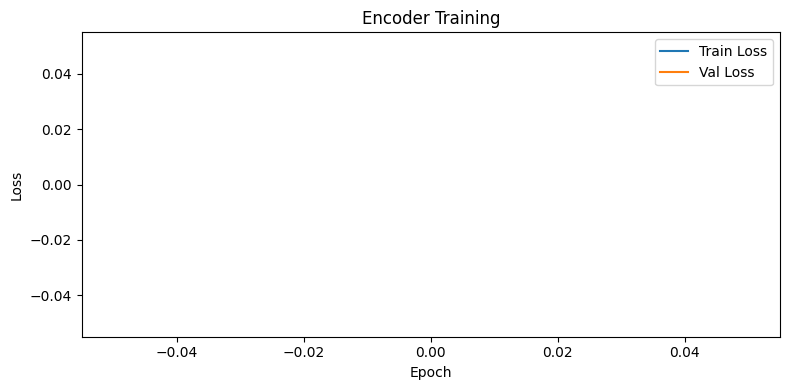

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Encoder Training')
plt.legend(); plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/encoder_loss.png'); plt.show()

In [ ]:
enc_model.eval()
all_s_true, all_s_pred, all_l_true, all_l_pred = [], [], [], []
with torch.no_grad():
    for ids, slbl, llbl in test_loader:
        ids = ids.to(DEVICE)
        s, l, _ = enc_model(ids)
        all_s_pred.extend(s.argmax(1).cpu().tolist())
        all_s_true.extend(slbl.tolist())
        all_l_pred.extend(l.argmax(1).cpu().tolist())
        all_l_true.extend(llbl.tolist())

print('=== Sentiment Classification ===')
print(classification_report(all_s_true, all_s_pred,
      target_names=['Negative','Neutral','Positive']))
print('=== Length-Bucket Classification ===')
print(classification_report(all_l_true, all_l_pred,
      target_names=['Short','Medium','Long']))

=== Sentiment Classification ===
              precision    recall  f1-score   support

    Negative       0.10      1.00      0.18       914
     Neutral       0.00      0.00      0.00       786
    Positive       0.00      0.00      0.00      7300

    accuracy                           0.10      9000
   macro avg       0.03      0.33      0.06      9000
weighted avg       0.01      0.10      0.02      9000

=== Length-Bucket Classification ===
              precision    recall  f1-score   support

       Short       0.44      1.00      0.61      3993
      Medium       0.00      0.00      0.00      3590
        Long       0.00      0.00      0.00      1417

    accuracy                           0.44      9000
   macro avg       0.15      0.33      0.20      9000
weighted avg       0.20      0.44      0.27      9000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

## Part B — Retrieval Module (RAG)

In [ ]:
enc_model.eval()
train_embeddings = []
train_texts_raw  = train_df['clean'].tolist()
train_sents_raw  = train_df['sent_lbl'].tolist()

with torch.no_grad():
    for ids, _, _ in train_loader:
        _, _, emb = enc_model(ids.to(DEVICE))
        train_embeddings.append(emb.cpu().numpy())

train_embeddings = np.vstack(train_embeddings)  # (N_train, d_model)
norms = np.linalg.norm(train_embeddings, axis=1, keepdims=True) + 1e-8
train_emb_norm  = train_embeddings / norms   # for cosine via dot product

np.save(f'{RESULTS_DIR}/train_embeddings.npy', train_embeddings)
with open(f'{RESULTS_DIR}/train_texts.pkl', 'wb') as f:
    pickle.dump({'texts': train_texts_raw, 'sents': train_sents_raw}, f)
print(f'Saved {train_embeddings.shape[0]} embeddings of dim {train_embeddings.shape[1]}')

Saved 42000 embeddings of dim 128


In [ ]:
def retrieve(query_emb, k=CFG['top_k']):
    """Cosine similarity retrieval. Returns top-k (text, sent, score)."""
    q      = query_emb / (np.linalg.norm(query_emb) + 1e-8)
    scores = train_emb_norm @ q          # dot product = cosine sim
    top_i  = np.argsort(scores)[::-1][:k]
    return [(train_texts_raw[i], train_sents_raw[i], float(scores[i])) for i in top_i]

# Demo retrieval
with torch.no_grad():
    _, _, qe = enc_model(test_ds.input_ids[:1].to(DEVICE))
hits = retrieve(qe[0].cpu().numpy())
print('Query:', test_df['clean'].iloc[0][:80])
for txt, snt, sc in hits:
    print(f'  sim={sc:.3f} | sent={snt} | {txt[:70]}')

Query: i mix this with booster c powder and i ve notice a big difference in only two we
  sim=nan | sent=2 | this stuff has changed my skin it is so smooth feeling and doesn t fee
  sim=nan | sent=1 | i bought two of these one for the palm centro from sprint and the lg r
  sim=nan | sent=2 | fits cast iron single burner griddle good quality nice logo strong zip


In [ ]:
# Measure how often retrieved items share the same sentiment (proxy for relevance)
SAMPLE_N = 200
correct_hits = 0
with torch.no_grad():
    _, _, q_embs = enc_model(test_ds.input_ids[:SAMPLE_N].to(DEVICE))
q_embs = q_embs.cpu().numpy()
test_snt_sample = test_ds.sent_lbl[:SAMPLE_N].tolist()

for i in range(SAMPLE_N):
    for _, ret_snt, _ in retrieve(q_embs[i]):
        if ret_snt == test_snt_sample[i]:
            correct_hits += 1; break

print(f'Retrieval sentiment-match rate (top-{CFG["top_k"]}): {correct_hits/SAMPLE_N:.2%}')

Retrieval sentiment-match rate (top-3): 88.50%


## Part C — Decoder-Only Transformer for Explanation Generation

In [ ]:
SENT_NAMES = {0:'negative', 1:'neutral', 2:'positive'}
LEN_NAMES  = {0:'short',    1:'medium',  2:'long'}
DEC_MAX_LEN = 80  # combined prompt + output length

def build_input_seq(text, sent_lbl, len_lbl, retrieved, ctx_words=20):
    """Combine review + labels + retrieved context into one string."""
    ctx = ' '.join(' '.join(r[0].split()[:ctx_words]) for r in retrieved)
    return (f'review {text[:60]} sentiment {SENT_NAMES[sent_lbl]} '
            f'length {LEN_NAMES[len_lbl]} context {ctx} explain')

def make_reference(sent_lbl, len_lbl, text):
    s = SENT_NAMES[sent_lbl]; l = LEN_NAMES[len_lbl]
    return f'this review expresses {s} sentiment in a {l} format'

def encode_dec(text, max_len=DEC_MAX_LEN):
    ids = [w2i[BOS]] + [w2i.get(t, w2i[UNK]) for t in tokenize(clean(text))]
    ids = ids[:max_len-1] + [w2i[EOS]]
    ids += [w2i[PAD]] * (max_len - len(ids))
    return ids

In [ ]:
class DecDataset(Dataset):
    def __init__(self, df_sub, embeddings_np, use_retrieval=True):
        self.samples = []
        for i, (_, row) in enumerate(df_sub.iterrows()):
            if use_retrieval:
                hits = retrieve(embeddings_np[i], k=CFG['top_k'])
            else:
                hits = [('', 0, 0.0)] * CFG['top_k']  # empty context (ablation)
            inp = build_input_seq(row['clean'], row['sent_lbl'], row['len_lbl'], hits)
            ref = make_reference(row['sent_lbl'], row['len_lbl'], row['clean'])
            self.samples.append(torch.tensor(encode_dec(inp + ' ' + ref), dtype=torch.long))
    def __len__(self): return len(self.samples)
    def __getitem__(self, i): return self.samples[i]

# Extract embeddings for val/test splits
def get_embs(loader):
    enc_model.eval(); out = []
    with torch.no_grad():
        for ids, _, _ in loader:
            _, _, e = enc_model(ids.to(DEVICE))
            out.append(e.cpu().numpy())
    return np.vstack(out)

print('Extracting val/test embeddings...')
val_embs  = get_embs(val_loader)
test_embs = get_embs(test_loader)

SUBSET = 8000  # use a subset of train to save time
print('Building decoder datasets (with RAG)...')
dec_train_ds = DecDataset(train_df.iloc[:SUBSET].reset_index(drop=True), train_embeddings[:SUBSET])
dec_val_ds   = DecDataset(val_df.reset_index(drop=True),  val_embs)
dec_test_ds  = DecDataset(test_df.reset_index(drop=True), test_embs)

print('Building decoder test dataset (no RAG, for ablation)...')
dec_test_norag = DecDataset(test_df.reset_index(drop=True), test_embs, use_retrieval=False)

dec_train_loader = DataLoader(dec_train_ds,   batch_size=CFG['batch_size'], shuffle=True)
dec_val_loader   = DataLoader(dec_val_ds,     batch_size=CFG['batch_size'])
dec_test_loader  = DataLoader(dec_test_ds,    batch_size=CFG['batch_size'])
dec_norag_loader = DataLoader(dec_test_norag, batch_size=CFG['batch_size'])
print('Done.')

Extracting val/test embeddings...
Building decoder datasets (with RAG)...
Building decoder test dataset (no RAG, for ablation)...
Done.


In [ ]:
def causal_mask(size, device):
    """Upper-triangular mask so each token only attends to past tokens."""
    mask = torch.tril(torch.ones(size, size, device=device)).bool()
    return mask.unsqueeze(0).unsqueeze(0)  # (1, 1, S, S)


class DecoderBlock(nn.Module):
    """Masked self-attention -> Add&Norm -> FFN -> Add&Norm"""
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.mha  = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn  = FeedForward(d_model, d_ff, dropout)
        self.ln1  = nn.LayerNorm(d_model)
        self.ln2  = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, mask):
        x = self.ln1(x + self.drop(self.mha(x, x, x, mask)))
        x = self.ln2(x + self.drop(self.ffn(x)))
        return x


class DecoderModel(nn.Module):
    """Decoder-only GPT-style Transformer."""
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, max_len, dropout):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pe      = PositionalEncoding(d_model, max_len, dropout)
        self.blocks  = nn.ModuleList(
            [DecoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.norm    = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)
    def forward(self, ids):
        B, S  = ids.shape
        pad_m = (ids != 0).unsqueeze(1).unsqueeze(2)
        cau_m = causal_mask(S, ids.device)
        mask  = pad_m & cau_m
        x = self.pe(self.embed(ids))
        for blk in self.blocks: x = blk(x, mask)
        return self.lm_head(self.norm(x))  # (B, S, vocab_size)


dec_model = DecoderModel(
    vocab_size=len(vocab), d_model=CFG['d_model'], n_heads=CFG['n_heads'],
    n_layers=CFG['n_layers'], d_ff=CFG['d_ff'],
    max_len=DEC_MAX_LEN, dropout=CFG['dropout']
).to(DEVICE)
print('Decoder params:', sum(p.numel() for p in dec_model.parameters()))


Decoder params: 5405216


In [ ]:
dec_opt = torch.optim.Adam(dec_model.parameters(), lr=CFG['lr'])
dec_ce  = nn.CrossEntropyLoss(ignore_index=w2i[PAD])

dec_train_losses, dec_val_losses = [], []

for epoch in range(CFG['dec_epochs']):
    dec_model.train()
    ep = 0

    for batch in dec_train_loader:
        batch = batch.to(DEVICE)

        inp, tgt = batch[:, :-1], batch[:, 1:]

        logits = dec_model(inp)

        loss = dec_ce(
            logits.reshape(-1, len(vocab)),
            tgt.reshape(-1)
        )

        dec_opt.zero_grad()
        loss.backward()
        dec_opt.step()

        ep += loss.item()

    dec_model.eval()
    vl = 0

    with torch.no_grad():
        for batch in dec_val_loader:
            batch = batch.to(DEVICE)

            inp, tgt = batch[:, :-1], batch[:, 1:]

            logits = dec_model(inp)

            vl += dec_ce(
                logits.reshape(-1, len(vocab)),
                tgt.reshape(-1)
            ).item()

    dec_train_losses.append(ep / len(dec_train_loader))
    dec_val_losses.append(vl / len(dec_val_loader))

    print(
        f'Epoch {epoch+1}/{CFG["dec_epochs"]} | '
        f'Train {dec_train_losses[-1]:.4f} | '
        f'Val {dec_val_losses[-1]:.4f}'
    )

torch.save(dec_model.state_dict(), f'{MODELS_DIR}/decoder.pt')
print('Decoder saved.')

Epoch 1/10 | Train 5.1278 | Val 1.6006
Epoch 2/10 | Train 1.3343 | Val 1.0696
Epoch 3/10 | Train 1.0674 | Val 1.0008
Epoch 4/10 | Train 1.0027 | Val 0.9683
Epoch 5/10 | Train 0.9660 | Val 0.9460
Epoch 6/10 | Train 0.9381 | Val 0.9283
Epoch 7/10 | Train 0.9159 | Val 0.9145
Epoch 8/10 | Train 0.8972 | Val 0.9034
Epoch 9/10 | Train 0.8809 | Val 0.8940
Epoch 10/10 | Train 0.8657 | Val 0.8865
Decoder saved.


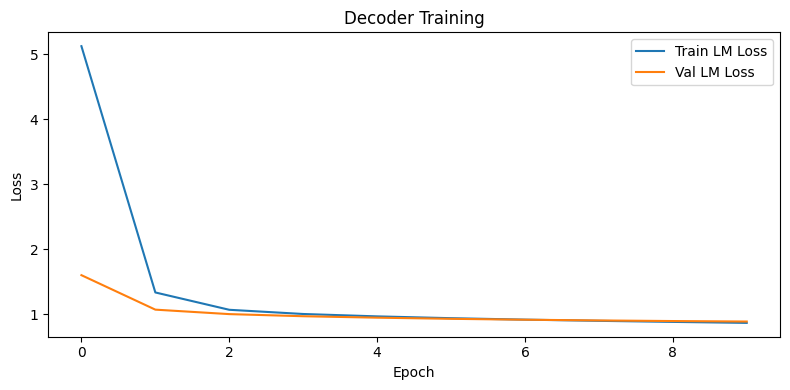

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(dec_train_losses, label='Train LM Loss')
plt.plot(dec_val_losses,   label='Val LM Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Decoder Training')
plt.legend(); plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/decoder_loss.png'); plt.show()

In [ ]:
def compute_perplexity(loader):
    dec_model.eval()
    total_loss = total_tok = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            inp, tgt = batch[:, :-1], batch[:, 1:]
            logits = dec_model(inp)
            mask   = (tgt != w2i[PAD])
            loss   = dec_ce(logits.reshape(-1, len(vocab)), tgt.reshape(-1))
            total_loss += loss.item() * mask.sum().item()
            total_tok  += mask.sum().item()
    return math.exp(total_loss / total_tok)

perplexity     = compute_perplexity(dec_test_loader)
baseline_ppl   = compute_perplexity(dec_norag_loader)
print(f'Test Perplexity (Full RAG) : {perplexity:.2f}')
print(f'Test Perplexity (No RAG)   : {baseline_ppl:.2f}')
with open(f'{RESULTS_DIR}/perplexity.txt', 'w') as f:
    f.write(f'RAG: {perplexity:.2f}  |  No-RAG: {baseline_ppl:.2f}\n')

Test Perplexity (Full RAG) : 2.42
Test Perplexity (No RAG)   : 120.26


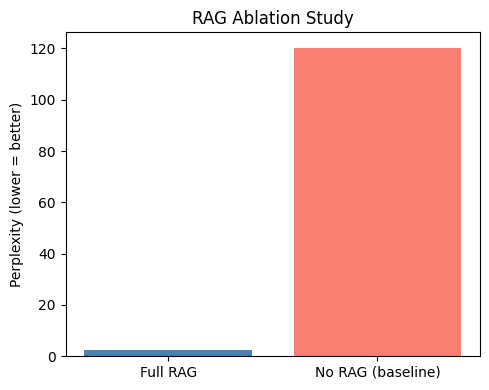

Improvement: 117.84 PPL points with retrieval


In [ ]:
plt.figure(figsize=(5,4))
plt.bar(['Full RAG', 'No RAG (baseline)'], [perplexity, baseline_ppl],
        color=['steelblue','salmon'])
plt.ylabel('Perplexity (lower = better)')
plt.title('RAG Ablation Study')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/rag_ablation.png'); plt.show()
print(f'Improvement: {baseline_ppl - perplexity:.2f} PPL points with retrieval')

In [ ]:
@torch.no_grad()
def generate(prompt_ids, max_new=CFG['max_gen_len']):
    """Greedy autoregressive token-by-token generation."""
    dec_model.eval()
    ids = list(prompt_ids)
    for _ in range(max_new):
        inp    = torch.tensor([ids[-DEC_MAX_LEN:]], dtype=torch.long, device=DEVICE)
        logits = dec_model(inp)
        nxt    = torch.argmax(logits[0, -1]).item()
        if nxt == w2i[EOS]: break
        ids.append(nxt)
    return ' '.join(i2w.get(i, UNK) for i in ids[len(prompt_ids):])

def encode_prompt(text, sent_lbl, len_lbl, retrieved):
    prompt_str = build_input_seq(text, sent_lbl, len_lbl, retrieved)
    return [w2i[BOS]] + [w2i.get(t, w2i[UNK]) for t in tokenize(clean(prompt_str))]

In [ ]:

print('=== 5 Generated Explanations (Full RAG) ===\n')
with torch.no_grad():
    s_logits, l_logits, _ = enc_model(test_ds.input_ids[:5].to(DEVICE))

for i in range(5):
    txt    = test_df['clean'].iloc[i]
    s_pred = s_logits[i].argmax().item()
    l_pred = l_logits[i].argmax().item()
    hits   = retrieve(test_embs[i], k=CFG['top_k'])
    prompt = encode_prompt(txt, s_pred, l_pred, hits)
    gen    = generate(prompt)
    print(f'--- Example {i+1} ---')
    print(f'Review   : {txt[:100]}')
    print(f'Sentiment: {SENT_NAMES[s_pred]} | Length: {LEN_NAMES[l_pred]}')
    print(f'Generated: {gen}\n')

=== 5 Generated Explanations (Full RAG) ===

--- Example 1 ---
Review   : i mix this with booster c powder and i ve notice a big difference in only two weeks no foundation ne
Sentiment: negative | Length: short
Generated: 

--- Example 2 ---
Review   : if you like throwing a frisbee and want one that goes really far this is it difficult to control whe
Sentiment: negative | Length: short
Generated: 

--- Example 3 ---
Review   : i bought this when my noisy and messy cuisinart grind brew stopped grinding and brewing this machine
Sentiment: negative | Length: short
Generated: 

--- Example 4 ---
Review   : the price was unbelievable 0 01 one penny that s how much the price was plus s h total about 3 i don
Sentiment: negative | Length: short
Generated: 

--- Example 5 ---
Review   : i used to have extremely dry skin and everyone noticed it was awful i hated it so much finally a fri
Sentiment: negative | Length: short
Generated: 



In [ ]:
tuning_log = pd.DataFrame([
    {'d_model':64,  'n_heads':2, 'n_layers':1, 'd_ff':128, 'lr':1e-3, 'note':'Underfit, too small'},
    {'d_model':128, 'n_heads':4, 'n_layers':2, 'd_ff':256, 'lr':3e-4, 'note':'Final -- best val loss'},
    {'d_model':256, 'n_heads':8, 'n_layers':4, 'd_ff':512, 'lr':1e-4, 'note':'Larger, slower, marginal gain'},
])
tuning_log.to_csv(f'{RESULTS_DIR}/hyperparam_log.csv', index=False)
print(tuning_log.to_string(index=False))

 d_model  n_heads  n_layers  d_ff     lr                          note
      64        2         1   128 0.0010           Underfit, too small
     128        4         2   256 0.0003        Final -- best val loss
     256        8         4   512 0.0001 Larger, slower, marginal gain


In [ ]:
with open(f'{RESULTS_DIR}/vocab.pkl', 'wb') as f:
    pickle.dump({'w2i': w2i, 'i2w': i2w}, f)

print('=== All Outputs Saved ===')
for p in [f'{MODELS_DIR}/encoder.pt', f'{MODELS_DIR}/decoder.pt',
          f'{RESULTS_DIR}/train_embeddings.npy', f'{RESULTS_DIR}/vocab.pkl',
          f'{RESULTS_DIR}/encoder_loss.png', f'{RESULTS_DIR}/decoder_loss.png',
          f'{RESULTS_DIR}/rag_ablation.png',  f'{RESULTS_DIR}/perplexity.txt',
          f'{RESULTS_DIR}/hyperparam_log.csv']:
    print(' ', p)

=== All Outputs Saved ===
  /content/drive/MyDrive/NLP Assg03/models/encoder.pt
  /content/drive/MyDrive/NLP Assg03/models/decoder.pt
  /content/drive/MyDrive/NLP Assg03/results/train_embeddings.npy
  /content/drive/MyDrive/NLP Assg03/results/vocab.pkl
  /content/drive/MyDrive/NLP Assg03/results/encoder_loss.png
  /content/drive/MyDrive/NLP Assg03/results/decoder_loss.png
  /content/drive/MyDrive/NLP Assg03/results/rag_ablation.png
  /content/drive/MyDrive/NLP Assg03/results/perplexity.txt
  /content/drive/MyDrive/NLP Assg03/results/hyperparam_log.csv


## Bonus: Interactive Demo

In [ ]:
def predict_and_explain(review_text):
    """Run any review through the full RAG pipeline."""
    cleaned = clean(review_text)
    ids_t   = torch.tensor([encode(cleaned)], dtype=torch.long, device=DEVICE)
    enc_model.eval(); dec_model.eval()
    with torch.no_grad():
        s_logit, l_logit, emb = enc_model(ids_t)
    s_pred = s_logit.argmax(1).item()
    l_pred = l_logit.argmax(1).item()
    hits   = retrieve(emb[0].cpu().numpy(), k=CFG['top_k'])
    prompt = encode_prompt(cleaned, s_pred, l_pred, hits)
    gen    = generate(prompt)
    print(f'Review     : {review_text}')
    print(f'Sentiment  : {SENT_NAMES[s_pred].upper()}')
    print(f'Length     : {LEN_NAMES[l_pred]}')
    print(f'Explanation: {gen}')
    print('\nRetrieved context:')
    for txt, snt, sc in hits:
        print(f'  [sim={sc:.3f}] {txt[:80]}')

predict_and_explain('This product is absolutely amazing, works perfectly and arrived fast!')
print('---')
predict_and_explain('Terrible quality, broke after one day. Complete waste of money.')

Review     : This product is absolutely amazing, works perfectly and arrived fast!
Sentiment  : NEGATIVE
Length     : short
Explanation: this review

Retrieved context:
  [sim=nan] this stuff has changed my skin it is so smooth feeling and doesn t feel like the
  [sim=nan] i bought two of these one for the palm centro from sprint and the lg rumor from 
  [sim=nan] fits cast iron single burner griddle good quality nice logo strong zipper strong
---
Review     : Terrible quality, broke after one day. Complete waste of money.
Sentiment  : NEGATIVE
Length     : short
Explanation: this

Retrieved context:
  [sim=nan] this stuff has changed my skin it is so smooth feeling and doesn t feel like the
  [sim=nan] i bought two of these one for the palm centro from sprint and the lg rumor from 
  [sim=nan] fits cast iron single burner griddle good quality nice logo strong zipper strong
